# Notebook 2 - Model Training & RCA Predictions

**Amac:** Multimodal veri kumesinden oznitelik cikarma, model egitimi ve degerlendirme.

Bu notebookta:
1. Veri yukleme ve oznitelik cikarma
2. Anomali tespit modeli egitimi (Random Forest)
3. Kok neden analizi siniflandiricilari
4. Performans metrikleri ve gorsellestirme
5. Self-Remediation onerileri

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, f1_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

from models.data_loader import MultimodalDataLoader

plt.style.use('dark_background')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Tum moduller yuklendi.')

Tum moduller yuklendi.


---
## 1 - Veri Yukleme ve Oznitelik Cikarma

In [2]:
# Veri yukleyiciyi hazirla (noise_level ve feature_dropout ile gercekci)
loader = MultimodalDataLoader(noise_level=0.25, feature_dropout=0.08)
loader.load_metadata()

📋 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000


,sample_id,layer,layer_name,is_anomaly,scenario_id,scenario_name,root_cause_category,severity,log_path,metrics_path,dashboard_path,label_path
0,sample_000001,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000001.txt,metrics/sample_000001.csv,dashboards/sample_000001.png,labels/sample_000001.json
1,sample_000002,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000002.txt,metrics/sample_000002.csv,dashboards/sample_000002.png,labels/sample_000002.json
2,sample_000003,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000003.txt,metrics/sample_000003.csv,dashboards/sample_000003.png,labels/sample_000003.json
3,sample_000004,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000004.txt,metrics/sample_000004.csv,dashboards/sample_000004.png,labels/sample_000004.json
4,sample_000005,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000005.txt,metrics/sample_000005.csv,dashboards/sample_000005.png,labels/sample_000005.json
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,sample_009996,linux_host,Linux Host (Physical Machine),1,HOST_002,Disk Error Count Increase,hardware,critical,logs/sample_009996.txt,metrics/sample_009996.csv,dashboards/sample_009996.png,labels/sample_009996.json
9996,sample_009997,linux_host,Linux Host (Physical Machine),1,HOST_002,Disk Error Count Increase,hardware,critical,logs/sample_009997.txt,metrics/sample_009997.csv,dashboards/sample_009997.png,labels/sample_009997.json
9997,sample_009998,linux_host,Linux Host (Physical Machine),1,HOST_002,Disk Error Count Increase,hardware,critical,logs/sample_009998.txt,metrics/sample_009998.csv,dashboards/sample_009998.png,labels/sample_009998.json
9998,sample_009999,linux_host,Linux Host (Physical Machine),1,HOST_002,Disk Error Count Increase,hardware,critical,logs/sample_009999.txt,metrics/sample_009999.csv,dashboards/sample_009999.png,labels/sample_009999.json


In [3]:
# Tum modalitelerden oznitelik cikar
start = time.time()
data = loader.build_feature_matrix(include_tfidf=True)
print(f'\nOznitelik cikarma suresi: {time.time() - start:.1f}s')


🔨 Building feature matrix for 10,000 samples...
   Processed 2,000/10,000 samples...
   Processed 4,000/10,000 samples...
   Processed 6,000/10,000 samples...
   Processed 8,000/10,000 samples...
   Processed 10,000/10,000 samples...
   ✅ Extracted features for 10,000 samples (skipped 0)
   🔧 Applying noise (level=0.25, dropout=0.08)...
   📝 Building TF-IDF matrix...
      TF-IDF shape: (10000, 100)
   🏷️ y_root_cause: 6 classes → ['config', 'hardware', 'network', 'none', 'resource', 'software']
   🏷️ y_severity: 4 classes → ['critical', 'high', 'medium', 'none']
   🏷️ y_layer: 11 classes → ['application', 'cdn', 'database', 'firewall', 'kubernetes_deployments', 'kubernetes_ingress', 'linux_host', 'linux_vm', 'network', 'proxy', 'storage']
   🏷️ y_scenario: 23 classes → ['APP_001', 'APP_002', 'CDN_001', 'CDN_002', 'DB_001', 'DB_002', 'FW_001', 'FW_002', 'HOST_001', 'HOST_002', 'K8D_001', 'K8D_002', 'K8I_001', 'K8I_002', 'NET_001', 'NET_002', 'PRX_001', 'PRX_002', 'STR_001', 'STR_002',

In [4]:
# Oznitelik matrisi detaylari
print('=== Oznitelik Matrisi ===')
print(f'Metrik oznitelikleri: {data["X_metrics"].shape}')
print(f'Log oznitelikleri:    {data["X_logs"].shape}')
if data["X_tfidf"] is not None:
    print(f'TF-IDF oznitelikleri: {data["X_tfidf"].shape}')
print(f'Toplam ornek sayisi: {len(data["sample_ids"]):,}')

=== Oznitelik Matrisi ===
Metrik oznitelikleri: (10000, 104)
Log oznitelikleri:    (10000, 9)
TF-IDF oznitelikleri: (10000, 100)
Toplam ornek sayisi: 10,000


In [5]:
# Train / Test bolme
X_metrics = data['X_metrics'].values
X_logs = data['X_logs'].values
X_combined = np.hstack([X_metrics, X_logs])
if data['X_tfidf'] is not None:
    from scipy.sparse import issparse
    tfidf_dense = data['X_tfidf'].toarray() if issparse(data['X_tfidf']) else data['X_tfidf']
    X_all = np.hstack([X_combined, tfidf_dense])
else:
    X_all = X_combined

y_anomaly = data['y_anomaly']
y_root_cause = data['y_root_cause']
y_severity = data['y_severity']
y_layer = data['y_layer']
y_scenario = data['y_scenario']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_anomaly, test_size=0.2, random_state=42, stratify=y_anomaly)

# Ayni split indekslerini RCA icin de kullan
_, _, y_rc_train, y_rc_test = train_test_split(
    X_all, y_root_cause, test_size=0.2, random_state=42, stratify=y_anomaly)
_, _, y_sev_train, y_sev_test = train_test_split(
    X_all, y_severity, test_size=0.2, random_state=42, stratify=y_anomaly)
_, _, y_lay_train, y_lay_test = train_test_split(
    X_all, y_layer, test_size=0.2, random_state=42, stratify=y_anomaly)
_, _, y_sc_train, y_sc_test = train_test_split(
    X_all, y_scenario, test_size=0.2, random_state=42, stratify=y_anomaly)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Features: {X_train.shape[1]}')

Train: 8,000 | Test: 2,000
Features: 213


---
## 2 - Anomali Tespit Modeli (Binary Classification)

In [6]:
# Random Forest ile anomali tespit modeli egitimi
rf_detector = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_detector.fit(X_train, y_train)

y_pred = rf_detector.predict(X_test)
y_prob = rf_detector.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Anomaly Detection - Accuracy: {acc:.4f}, F1: {f1:.4f}')

Anomaly Detection - Accuracy: 0.9845, F1: 0.9845


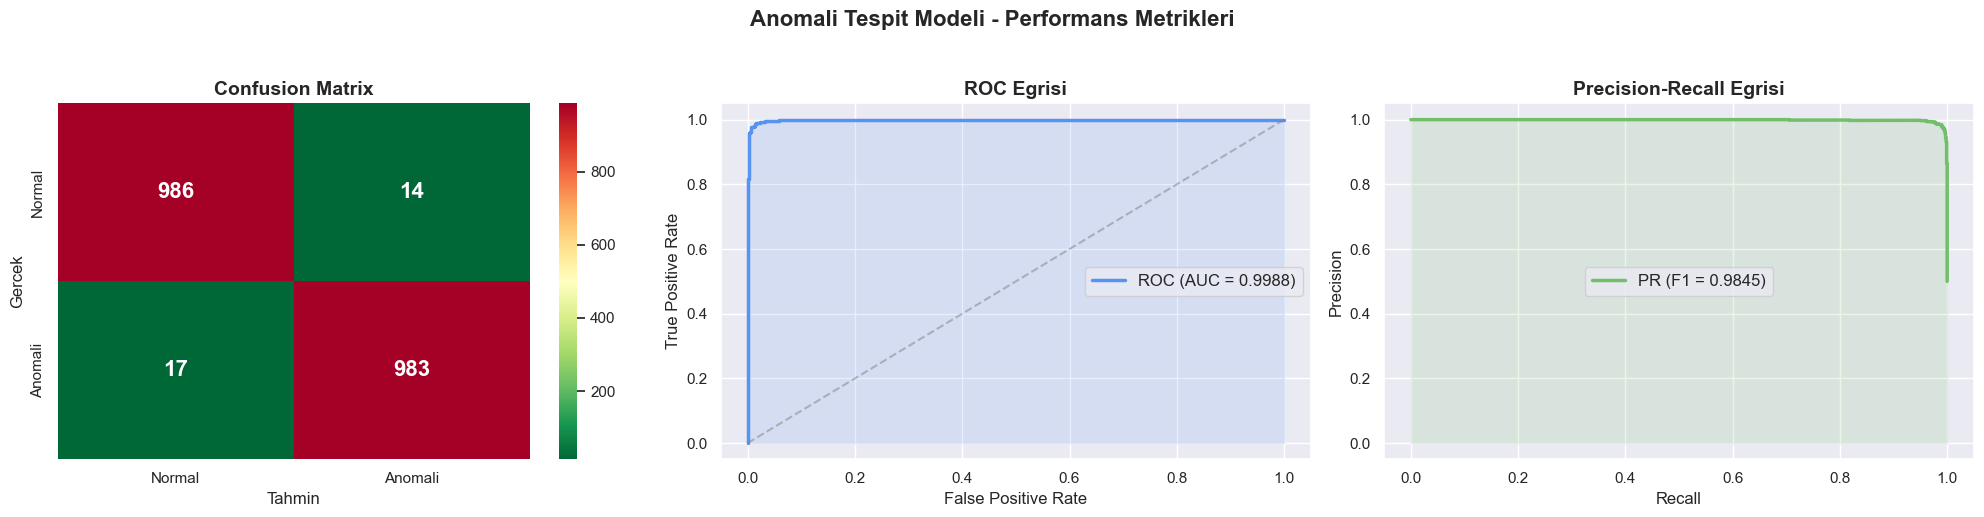

In [7]:
# Confusion Matrix + ROC + Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[0],
           xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'],
           annot_kws={'size': 16, 'fontweight': 'bold'})
axes[0].set_xlabel('Tahmin', fontsize=12)
axes[0].set_ylabel('Gercek', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#5794f2', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#5794f2')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Egrisi', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color='#73bf69', lw=2.5, label=f'PR (F1 = {f1:.4f})')
axes[2].fill_between(rec, prec, alpha=0.15, color='#73bf69')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision-Recall Egrisi', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=12)

plt.suptitle('Anomali Tespit Modeli - Performans Metrikleri', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

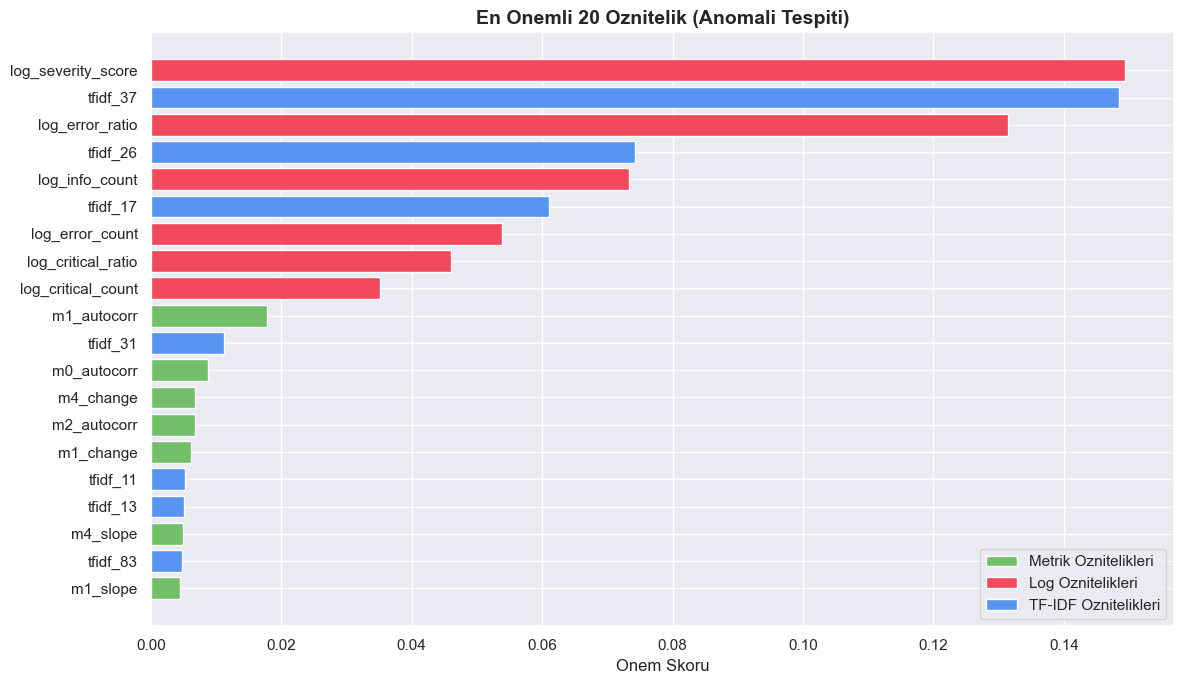

In [8]:
# Oznitelik onem siralamasi
feature_names = list(data['X_metrics'].columns) + list(data['X_logs'].columns)
if data['X_tfidf'] is not None:
    feature_names += [f'tfidf_{i}' for i in range(data['X_tfidf'].shape[1])]

fi = pd.DataFrame({'feature': feature_names, 'importance': rf_detector.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#f2495c' if 'log_' in f else '#5794f2' if 'tfidf' in f else '#73bf69'
          for f in fi['feature']]
ax.barh(range(len(fi)), fi['importance'].values, color=colors)
ax.set_yticks(range(len(fi)))
ax.set_yticklabels(fi['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Onem Skoru', fontsize=12)
ax.set_title('En Onemli 20 Oznitelik (Anomali Tespiti)', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#73bf69', label='Metrik Oznitelikleri'),
    Patch(facecolor='#f2495c', label='Log Oznitelikleri'),
    Patch(facecolor='#5794f2', label='TF-IDF Oznitelikleri'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3 - Kok Neden Analizi (RCA) Siniflandiricilari

In [9]:
# RCA siniflandiricilari egit (sadece anomali ornekleri)
anom_train_mask = y_train == 1
anom_test_mask = y_test == 1
X_train_anom = X_train[anom_train_mask]
X_test_anom = X_test[anom_test_mask]

rca_targets = {
    'Root Cause (5 sinif)': (y_rc_train[anom_train_mask], y_rc_test[anom_test_mask], 'y_root_cause'),
    'Severity (3 sinif)': (y_sev_train[anom_train_mask], y_sev_test[anom_test_mask], 'y_severity'),
    'Layer (11 sinif)': (y_lay_train[anom_train_mask], y_lay_test[anom_test_mask], 'y_layer'),
    'Scenario (22 sinif)': (y_sc_train[anom_train_mask], y_sc_test[anom_test_mask], 'y_scenario'),
}

rca_models = {}
rca_results = {}

for name, (y_tr, y_te, key) in rca_targets.items():
    n_classes = len(np.unique(y_tr))
    model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_train_anom, y_tr)
    y_pred_rca = model.predict(X_test_anom)
    
    acc_rca = accuracy_score(y_te, y_pred_rca)
    f1_rca = f1_score(y_te, y_pred_rca, average='weighted')
    
    rca_models[key] = model
    rca_results[name] = {'accuracy': acc_rca, 'f1': f1_rca, 'n_classes': n_classes}
    print(f'{name}: Accuracy={acc_rca:.4f}, F1={f1_rca:.4f}')

Root Cause (5 sinif): Accuracy=0.9990, F1=0.9990
Severity (3 sinif): Accuracy=0.9980, F1=0.9980
Layer (11 sinif): Accuracy=1.0000, F1=1.0000
Scenario (22 sinif): Accuracy=0.9910, F1=0.9910


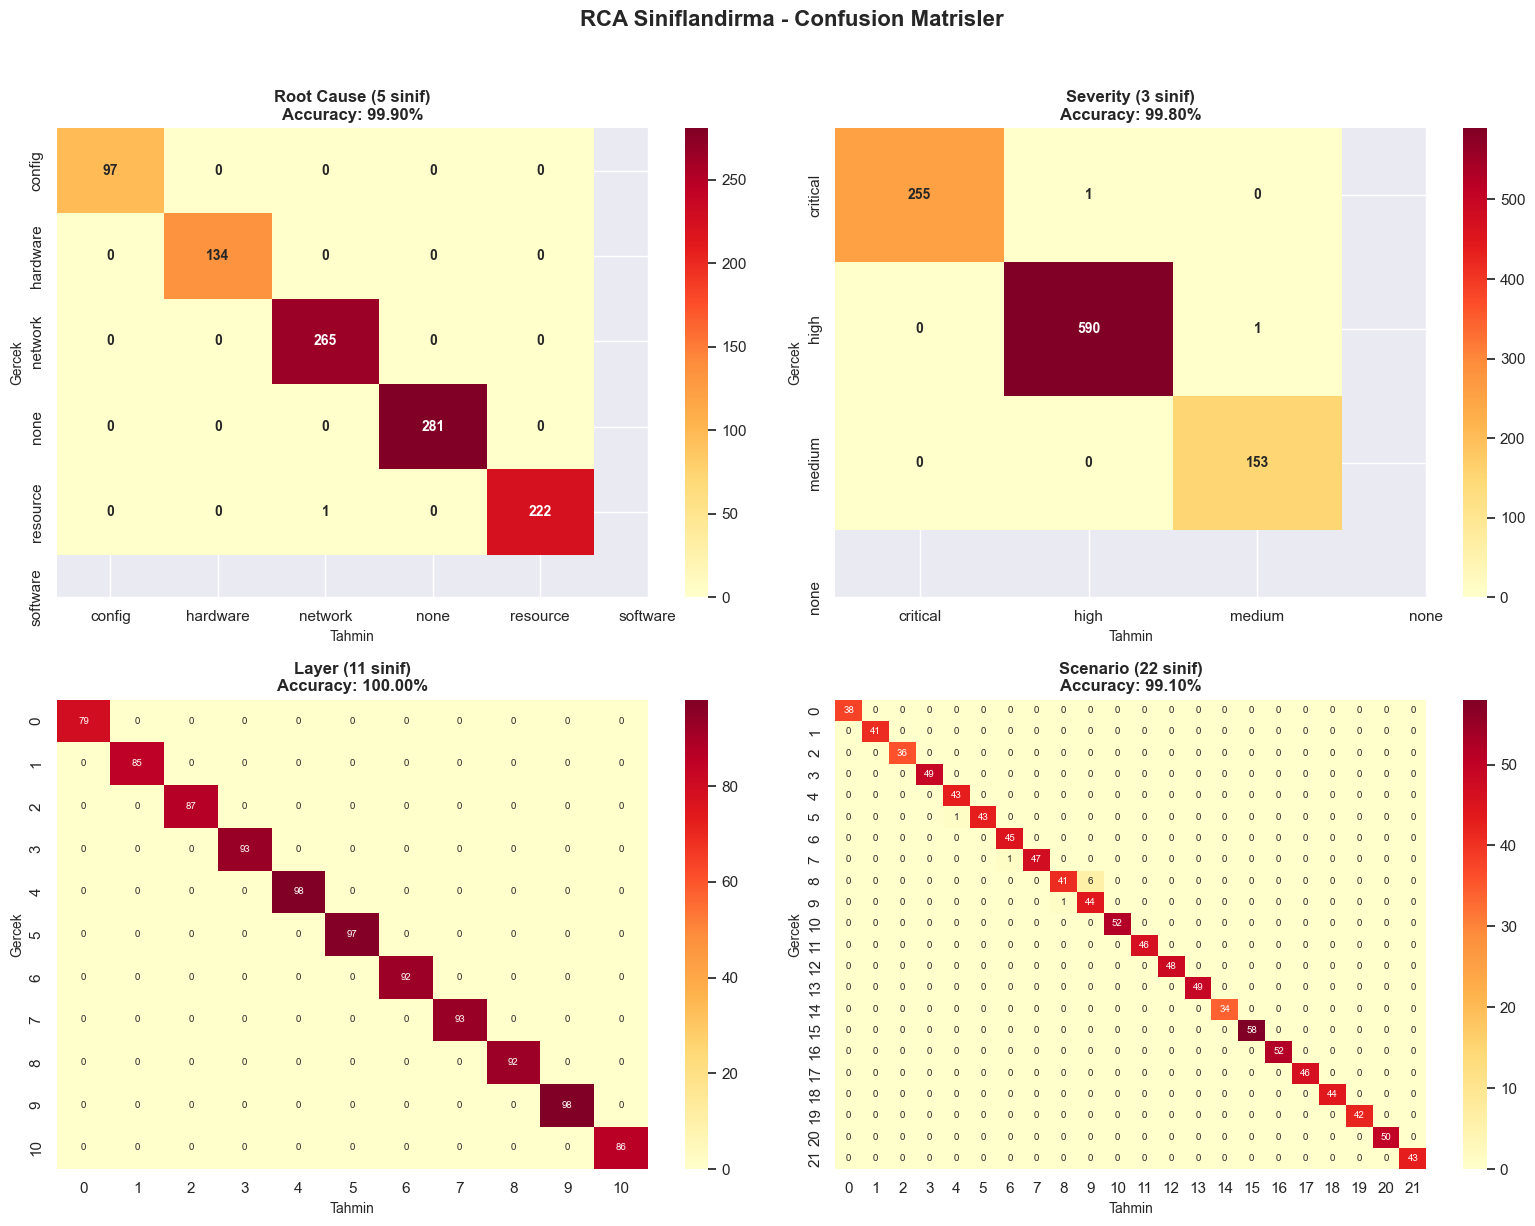

In [10]:
# RCA Confusion Matrisler
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (name, (y_tr, y_te, key)) in enumerate(rca_targets.items()):
    ax = axes[idx // 2][idx % 2]
    model = rca_models[key]
    y_pred_rca = model.predict(X_test_anom)
    cm = confusion_matrix(y_te, y_pred_rca)
    
    le = loader.label_encoders[key]
    labels = le.classes_
    
    if len(labels) > 10:
        sns.heatmap(cm, ax=ax, cmap='YlOrRd', fmt='d', annot=True, annot_kws={'size': 7})
    else:
        sns.heatmap(cm, ax=ax, cmap='YlOrRd', fmt='d', annot=True,
                   xticklabels=labels, yticklabels=labels,
                   annot_kws={'size': 10, 'fontweight': 'bold'})
    
    acc_rca = rca_results[name]['accuracy']
    ax.set_title(f'{name}\nAccuracy: {acc_rca:.2%}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahmin', fontsize=10)
    ax.set_ylabel('Gercek', fontsize=10)

plt.suptitle('RCA Siniflandirma - Confusion Matrisler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4 - Performans Ozet Tablosu

In [11]:
# Genel performans ozeti
summary = {
    'Gorev': ['Anomali Tespiti'] + list(rca_results.keys()),
    'Sinif Sayisi': [2] + [r['n_classes'] for r in rca_results.values()],
    'Accuracy': [acc] + [r['accuracy'] for r in rca_results.values()],
    'F1 Score': [f1] + [r['f1'] for r in rca_results.values()],
}
summary_df = pd.DataFrame(summary)
summary_df.style.format({'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}'}).background_gradient(
    subset=['Accuracy', 'F1 Score'], cmap='RdYlGn', vmin=0.5, vmax=1.0)

,Gorev,Sinif Sayisi,Accuracy,F1 Score
0,Anomali Tespiti,2,0.9845,0.9845
1,Root Cause (5 sinif),5,0.9990,0.9990
2,Severity (3 sinif),3,0.9980,0.9980
3,Layer (11 sinif),11,1.0000,1.0000
4,Scenario (22 sinif),22,0.9910,0.9910


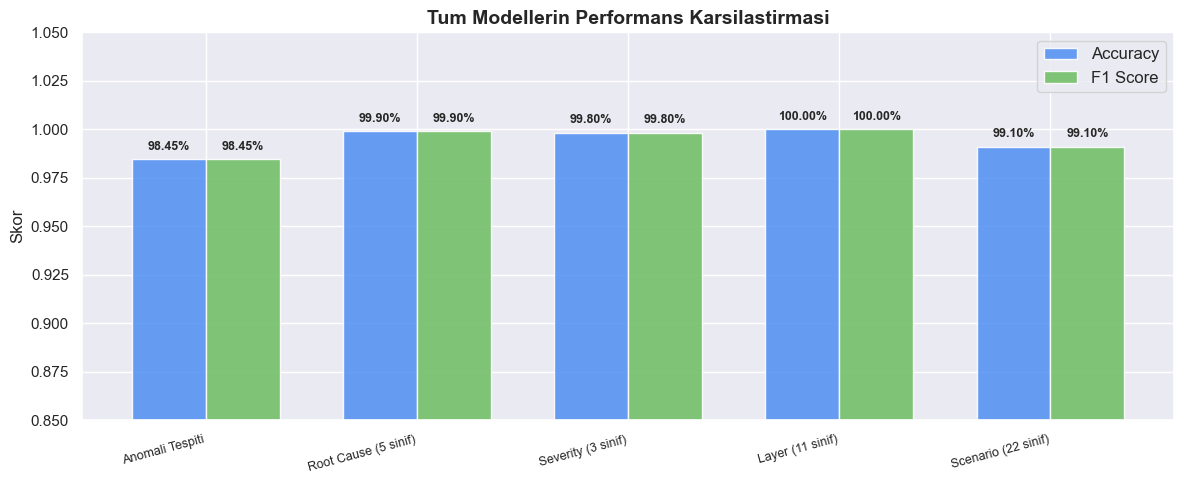

In [12]:
# Performans bar grafigi
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_df))
w = 0.35

bars1 = ax.bar(x - w/2, summary_df['Accuracy'], w, label='Accuracy', color='#5794f2', alpha=0.9)
bars2 = ax.bar(x + w/2, summary_df['F1 Score'], w, label='F1 Score', color='#73bf69', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Gorev'], fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Skor', fontsize=12)
ax.set_ylim(0.85, 1.05)
ax.set_title('Tum Modellerin Performans Karsilastirmasi', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5 - Self-Remediation (Otomatik Duzeltme Onerileri)

In [13]:
# Remediation onerileri
from models.rca_models import RemediationEngine

remediation = RemediationEngine()
le_scenario = loader.label_encoders['y_scenario']

# Scenario tahminlerini al
pred_scenarios = rca_models['y_scenario'].predict(X_test_anom)
pred_scenario_ids = le_scenario.inverse_transform(pred_scenarios)

print(f'Toplam anomali tahmini: {len(pred_scenario_ids)}')
print(f'Benzersiz senaryo sayisi: {len(set(pred_scenario_ids))}')

Toplam anomali tahmini: 1000
Benzersiz senaryo sayisi: 22


In [14]:
# 10 ornek remediation
print('='*70)
print('  SELF-REMEDIATION ONERILERI (10 Ornek)')
print('='*70)

for i in range(min(10, len(pred_scenario_ids))):
    sid = pred_scenario_ids[i]
    rem = remediation.get_remediation(sid)
    info = rem.get('info', {})

    print(f'\n--- Ornek {i+1} ---')
    print(f'  Senaryo:     {sid} - {info.get("name", "?")}')
    print(f'  Katman:      {info.get("layer", "?")}')
    print(f'  Kok Neden:   {info.get("root_cause", "?")}')
    print(f'  Siddet:      {info.get("severity", "?")}')
    print(f'  Aksiyonlar:')
    for action in rem.get('actions', []):
        print(f'    -> {action}')

  SELF-REMEDIATION ONERILERI (10 Ornek)

--- Ornek 1 ---
  Senaryo:     FW_002 - High Bandwidth Usage
  Katman:      firewall
  Kok Neden:   Excessive traffic or potential data exfiltration
  Siddet:      high
  Aksiyonlar:
    -> Trigger bandwidth limit control script
    -> Analyze network traffic

--- Ornek 2 ---
  Senaryo:     VM_002 - Memory Exhaustion
  Katman:      linux_vm
  Kok Neden:   Memory leak or high memory demand
  Siddet:      critical
  Aksiyonlar:
    -> Run memory cleanup script
    -> Monitor and optimize swap usage

--- Ornek 3 ---
  Senaryo:     NET_001 - Packet Loss Increase
  Katman:      network
  Kok Neden:   Network device issue or connectivity problem
  Siddet:      high
  Aksiyonlar:
    -> Renew connections
    -> Restart faulty network devices

--- Ornek 4 ---
  Senaryo:     CDN_001 - Sudden Traffic Spike
  Katman:      cdn
  Kok Neden:   Potential DDoS attack or temporary spike
  Siddet:      critical
  Aksiyonlar:
    -> Apply IP restrictions on firewa

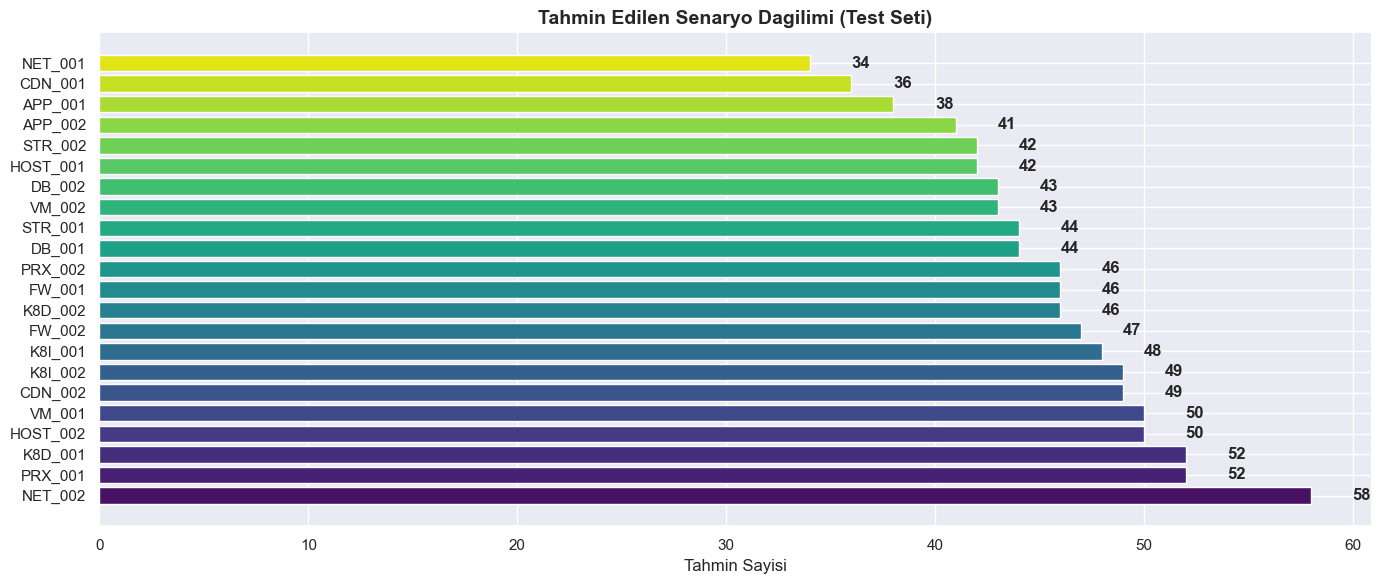

In [15]:
# Senaryo tahmin dagilimi
pred_series = pd.Series(pred_scenario_ids)
pred_counts = pred_series.value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(pred_counts.index, pred_counts.values, color=sns.color_palette('viridis', len(pred_counts)))
ax.set_xlabel('Tahmin Sayisi', fontsize=12)
ax.set_title('Tahmin Edilen Senaryo Dagilimi (Test Seti)', fontsize=14, fontweight='bold')
for i, v in enumerate(pred_counts.values):
    ax.text(v + 2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 - Pipeline Ozeti

In [16]:
print('\n' + '='*70)
print('  MULTIMODAL RCA ENGINE - SONUC OZETI')
print('='*70)
print(f'\n  Veri Kumesi:')
print(f'     Toplam ornek:     {len(data["sample_ids"]):>8,}')
print(f'     Oznitelik sayisi: {X_all.shape[1]:>7}')
print(f'\n  Anomali Tespiti:')
print(f'     Accuracy:   {acc:.4f}')
print(f'     F1 Score:   {f1:.4f}')
print(f'     AUC-ROC:    {roc_auc:.4f}')
print(f'\n  RCA Siniflandirma:')
for name, res in rca_results.items():
    print(f'     {name:<30s} Acc={res["accuracy"]:.4f}  F1={res["f1"]:.4f}')
print(f'\n  Self-Remediation:')
print(f'     22 senaryo icin otomatik aksiyon onerisi aktif')
print('='*70)
print('\nPipeline tamamlandi!')


  MULTIMODAL RCA ENGINE - SONUC OZETI

  Veri Kumesi:
     Toplam ornek:       10,000
     Oznitelik sayisi:     213

  Anomali Tespiti:
     Accuracy:   0.9845
     F1 Score:   0.9845
     AUC-ROC:    0.9988

  RCA Siniflandirma:
     Root Cause (5 sinif)           Acc=0.9990  F1=0.9990
     Severity (3 sinif)             Acc=0.9980  F1=0.9980
     Layer (11 sinif)               Acc=1.0000  F1=1.0000
     Scenario (22 sinif)            Acc=0.9910  F1=0.9910

  Self-Remediation:
     22 senaryo icin otomatik aksiyon onerisi aktif

Pipeline tamamlandi!
